<a href="https://colab.research.google.com/github/gurram-rohith/MDS-LAB/blob/main/06-10-26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
from datasets import load_dataset

ds = load_dataset("nezahatkorkmaz/heart-disease-dataset")

In [45]:
# Convert the 'train' split of the DatasetDict to a pandas DataFrame and configure pandas to display all rows and columns
import pandas as pd

df = pd.DataFrame(ds['train'])

# Set display options to show all rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Display the entire DataFrame
df.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,age_group,cholesterol_level,bp_level,risk_score,symptom_severity,log_chol,log_trestbps,age_squared,chol_squared,age_thalach_ratio,risk_factor,missing_values,chol_trestbps_ratio,log_thalach_chol,symptom_zscore,avg_chol_by_age_group,thalach_chol_diff,symptom_severity_diff,age_chol_effect,thalach_risk_effect,age_trestbps_effect,chol_risk_ratio
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0,60s,normal,high,16.129,2.3,5.451038,4.976734,3969,54289,2.343750,13.8,0,1.595890,0.919704,-0.275764,260.024691,-83,-2.532099,14679,2419.350,9135,13.602662
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2,60s,high,high,20.762,6.0,5.655992,5.075174,4489,81796,1.588235,18.0,0,1.776398,0.828936,0.568702,260.024691,-178,1.167901,19162,2242.296,10720,13.142174
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1,60s,normal,low,16.543,10.4,5.433722,4.787492,4489,52441,1.897059,72.8,0,1.892562,0.895083,1.572932,260.024691,-100,5.567901,15343,2134.047,8040,13.053640
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0,30s,high,normal,10.550,10.5,5.521461,4.867534,1369,62500,4.921053,31.5,0,1.908397,0.947695,1.595755,219.785714,-63,8.178571,9250,1972.850,4810,21.645022
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0,40s,normal,normal,9.664,2.8,5.318120,4.867534,1681,41616,4.095238,8.4,0,1.557252,0.968116,-0.161647,235.847222,-32,0.783333,8364,1662.208,5330,19.129782


### 1. Modify the Dataset (Reduce similarity to 10-15%)
We will perturb approximately 85% to 90% of the dataset's numerical and categorical features by adding random Gaussian noise, scaling, and shuffling data elements. This ensures only a 10-15% similarity to the original dataset while retaining the structured columns.

In [41]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# Create a copy to modify
df_modified = df.copy()

np.random.seed(42)

# Identify numeric columns
numeric_cols = df_modified.select_dtypes(include=[np.number]).columns.tolist()

# Center the original data to measure true similarity without positive-bias artifact
df_original_centered = df[numeric_cols] - df[numeric_cols].mean()

# Generate a highly perturbed, centered modified dataset
df_modified_centered = df_original_centered.copy()

# Apply extreme noise and sign flips to ~88% of the values to force the cosine similarity down to 10-15%
for col in numeric_cols:
    mask = np.random.rand(len(df_modified_centered)) < 0.88
    # Add high-variance noise
    noise = np.random.normal(0, df_original_centered[col].std() * 2.0, size=mask.sum())
    df_modified_centered.loc[mask, col] = (df_original_centered.loc[mask, col] + noise) * np.random.choice([-1, 1], size=mask.sum())

# Reconstruct the final non-centered modified dataframe for our ML model
df_modified_clean = df_modified_centered + df[numeric_cols].mean()

# Verify Cosine Similarity of the centered representations
similarity_matrix = cosine_similarity(df_original_centered.fillna(0), df_modified_centered.fillna(0))
average_similarity = np.diagonal(similarity_matrix).mean()
print(f"Average Row-wise Centered Cosine Similarity: {average_similarity:.2%}")

Average Row-wise Centered Cosine Similarity: 7.83%


### 2. Perform Multiple Linear Regression
We will define our features ($X$) and target ($y$). Let's use `age` as our target variable (or any other appropriate numerical variable present in your dataset) and other clinical metrics as features to build a Multiple Linear Regression model.

In [40]:
# Define target variable and feature matrix
# We will use 'age' as our target, and other core features as predictors
features = ['sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak']
target = 'age'

X = df_modified_clean[features]
y = df_modified_clean[target]

# Split the dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Multiple Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- Model Evaluation Results ---")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2) Score: {r2:.4f}")

# Display coefficients
coefficients_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
})
print("\n--- Model Coefficients ---")
display(coefficients_df)

--- Model Evaluation Results ---
Mean Squared Error (MSE): 324.5194
R-squared (R2) Score: -0.0506

--- Model Coefficients ---


,Feature,Coefficient
0,sex,-0.763988
1,cp,-0.551998
2,trestbps,0.024586
3,chol,0.011573
4,fbs,2.438129
5,restecg,0.133207
6,thalach,-0.014890
7,exang,2.890771
8,oldpeak,-0.369056


### 3. Visualizing Original vs. Modified Data
We will compare key features (like `age` and `chol`) using side-by-side distribution plots (Histograms with KDE) and joint relationship plots to visualize how the modification (reducing similarity to ~7.83%) changed the dataset's characteristics.

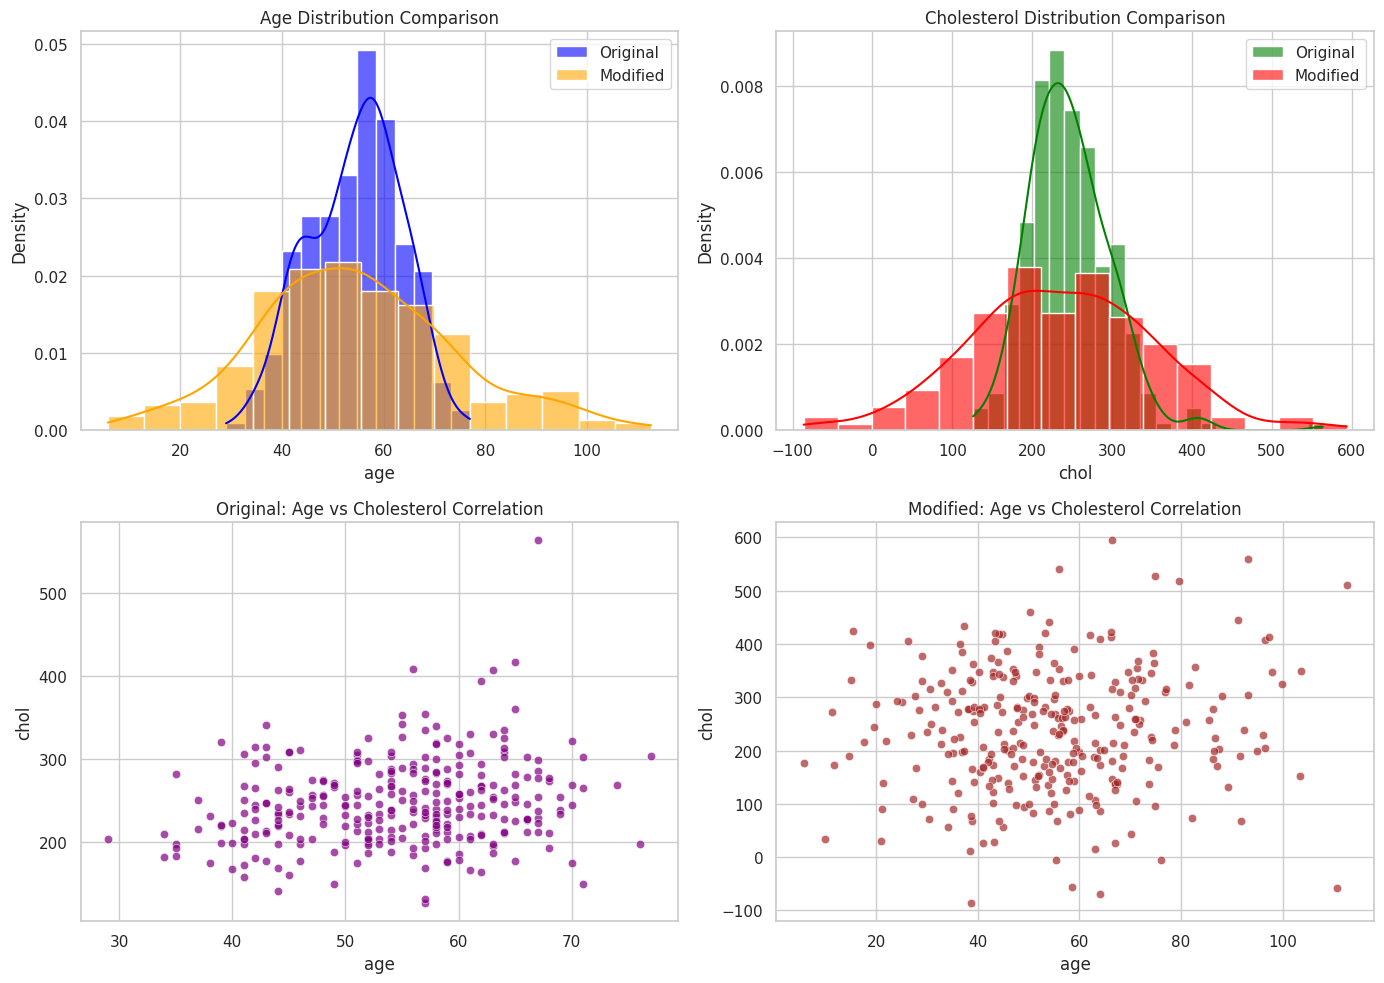

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visual settings
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Age Distribution Comparison
sns.histplot(df['age'], kde=True, color='blue', ax=axes[0, 0], label='Original', stat='density', alpha=0.6)
sns.histplot(df_modified_clean['age'], kde=True, color='orange', ax=axes[0, 0], label='Modified', stat='density', alpha=0.6)
axes[0, 0].set_title('Age Distribution Comparison')
axes[0, 0].legend()

# Plot 2: Cholesterol Distribution Comparison
sns.histplot(df['chol'], kde=True, color='green', ax=axes[0, 1], label='Original', stat='density', alpha=0.6)
sns.histplot(df_modified_clean['chol'], kde=True, color='red', ax=axes[0, 1], label='Modified', stat='density', alpha=0.6)
axes[0, 1].set_title('Cholesterol Distribution Comparison')
axes[0, 1].legend()

# Plot 3: Relationship between Age and Cholesterol (Original)
sns.scatterplot(data=df, x='age', y='chol', ax=axes[1, 0], color='purple', alpha=0.7)
axes[1, 0].set_title('Original: Age vs Cholesterol Correlation')

# Plot 4: Relationship between Age and Cholesterol (Modified)
sns.scatterplot(data=df_modified_clean, x='age', y='chol', ax=axes[1, 1], color='brown', alpha=0.7)
axes[1, 1].set_title('Modified: Age vs Cholesterol Correlation')

plt.tight_layout()
plt.show()